# Gold 06B — Test Early-Warning Validation

Gold 06B uses the row-level test replay output from Gold 06A and performs early-warning analysis on the held-out test rows.

This mirrors the purpose of Gold 05, but it is applied to the replayed test outputs rather than the original training/notebook outputs.


## 1. Imports and context


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping, Sequence

import json
import logging
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.core.file_io import load_json, save_json
from utils.core.notebook_context import load_notebook_context


In [2]:
CONTEXT_STAGE = "gold_test_early_warning_validation"
CONTEXT_DATASET = "pump"
CONTEXT_LAYER = "gold"
CONFIG_RUN_MODE = "test"
CONFIG_PROFILE = "default"
CONTEXT_LOG_FILE = "gold_test_early_warning_validation.log"

CTX = load_notebook_context(
    stage=CONTEXT_STAGE,
    dataset=CONTEXT_DATASET,
    mode=CONFIG_RUN_MODE,
    profile=CONFIG_PROFILE,
    logger_child_name="capstone.gold.test_early_warning_validation",
    log_filename=CONTEXT_LOG_FILE,
)

paths = CTX.paths
CONFIG = CTX.config
RESOLVED_PATHS = CTX.resolved_paths
logger = CTX.logger
ledger = CTX.ledger
LOG_PATH = CTX.log_path
CONTEXT_RECIPE_ID = CTX.recipe_id

DATASET_NAME = CONTEXT_DATASET
GOLD_ROOT = paths.artifacts / "gold" / DATASET_NAME
VALIDATION_ROOT = GOLD_ROOT / "model_replay_validation"
VALIDATION_SCORES_DIR = VALIDATION_ROOT / "scores"
VALIDATION_RESULTS_DIR = VALIDATION_ROOT / "results"
VALIDATION_SUMMARY_DIR = VALIDATION_ROOT / "summaries"
VALIDATION_PLOTS_DIR = VALIDATION_ROOT / "plots"

for directory in [VALIDATION_RESULTS_DIR, VALIDATION_SUMMARY_DIR, VALIDATION_PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ledger.add(
    kind="step",
    step="context_loaded",
    message="Loaded Gold 06B test early-warning validation context.",
    data={"stage": CONTEXT_STAGE, "dataset": DATASET_NAME, "log_path": str(LOG_PATH)},
    logger=logger,
)


2026-06-18 00:45:05,200 | INFO | capstone.gold.test_early_warning_validation | gold_test_early_warning_validation stage starting
2026-06-18 00:45:05,202 | INFO | capstone.gold.test_early_warning_validation | LEDGER | {'ts_utc': '2026-06-18T00:45:05.202182+00:00', 'stage': 'gold_test_early_warning_validation', 'recipe': 'gold_modeling__v001_test_early_warning_validation', 'kind': 'step', 'step': 'init', 'message': 'Initialized ledger from shared notebook context', 'why': None, 'consequence': None, 'data': {'stage': 'gold_test_early_warning_validation', 'recipe_id': 'gold_modeling__v001_test_early_warning_validation', 'dataset': 'pump', 'mode': 'test', 'profile': 'default', 'log_path': '/workspace/logs/gold_test_early_warning_validation.log'}}
2026-06-18 00:45:05,250 | INFO | capstone.gold.test_early_warning_validation | LEDGER | {'ts_utc': '2026-06-18T00:45:05.250850+00:00', 'stage': 'gold_test_early_warning_validation', 'recipe': 'gold_modeling__v001_test_early_warning_validation', 'ki

{'ts_utc': '2026-06-18T00:45:05.250850+00:00',
 'stage': 'gold_test_early_warning_validation',
 'recipe': 'gold_modeling__v001_test_early_warning_validation',
 'kind': 'step',
 'step': 'context_loaded',
 'message': 'Loaded Gold 06B test early-warning validation context.',
 'why': None,
 'consequence': None,
 'data': {'stage': 'gold_test_early_warning_validation',
  'dataset': 'pump',
  'log_path': '/workspace/logs/gold_test_early_warning_validation.log'}}

## 2. Load Gold 06A replay output

Gold 06B does not run the models again. Gold 06A already produced the replayed test-set flags and scores. This notebook focuses on the early-warning behavior of those replayed outputs.


In [3]:
REPLAY_SCORES_PATH = VALIDATION_SCORES_DIR / f"{DATASET_NAME}__gold06a__test_replay_scores.csv"
TRAIN_LEAD_TIME_PATH = GOLD_ROOT / "anomaly_detection" / "summaries" / "multi_run_lead_time_comparison.csv"

if not REPLAY_SCORES_PATH.exists():
    raise FileNotFoundError(
        f"Gold 06B needs the Gold 06A replay score output first: {REPLAY_SCORES_PATH}"
    )

replay_scores_dataframe = pd.read_csv(REPLAY_SCORES_PATH)

label_column_candidates = ["anomaly_flag", "is_anomaly", "target_flag", "label"]
label_column = next(
    (column for column in label_column_candidates if column in replay_scores_dataframe.columns),
    None,
)
if label_column is None:
    raise KeyError(f"Could not find label column. Checked: {label_column_candidates}")

if "plot_order_index" not in replay_scores_dataframe.columns:
    replay_scores_dataframe = replay_scores_dataframe.copy()
    replay_scores_dataframe["plot_order_index"] = np.arange(len(replay_scores_dataframe), dtype=int)

basic_input_check = {
    "replay_scores_path": str(REPLAY_SCORES_PATH),
    "row_count": int(len(replay_scores_dataframe)),
    "label_column": label_column,
    "anomaly_rows": int(replay_scores_dataframe[label_column].fillna(0).astype(int).sum()),
    "train_lead_time_artifact_available": bool(TRAIN_LEAD_TIME_PATH.exists()),
}

ledger.add(
    kind="check",
    step="gold06a_replay_scores_loaded",
    message="Loaded Gold 06A replay scores for test early-warning validation.",
    data=basic_input_check,
    logger=logger,
)

basic_input_check


2026-06-18 00:45:09,799 | INFO | capstone.gold.test_early_warning_validation | LEDGER | {'ts_utc': '2026-06-18T00:45:09.799098+00:00', 'stage': 'gold_test_early_warning_validation', 'recipe': 'gold_modeling__v001_test_early_warning_validation', 'kind': 'check', 'step': 'gold06a_replay_scores_loaded', 'message': 'Loaded Gold 06A replay scores for test early-warning validation.', 'why': None, 'consequence': None, 'data': {'replay_scores_path': '/workspace/artifacts/gold/pump/model_replay_validation/scores/pump__gold06a__test_replay_scores.csv', 'row_count': 83889, 'label_column': 'anomaly_flag', 'anomaly_rows': 118, 'train_lead_time_artifact_available': True}}


{'replay_scores_path': '/workspace/artifacts/gold/pump/model_replay_validation/scores/pump__gold06a__test_replay_scores.csv',
 'row_count': 83889,
 'label_column': 'anomaly_flag',
 'anomaly_rows': 118,
 'train_lead_time_artifact_available': True}

## 3. Early-warning helper functions

The key early-warning question is: how early does each model variant alert before the first failure/anomaly point in the held-out test rows?


In [4]:
def resolve_failure_flag(dataframe: pd.DataFrame, label_column: str) -> pd.Series:
    """
    Resolve the actual failure/anomaly flag used for early-warning timing.

    The label column is the fallback. If machine_status contains a BROKEN-like
    value, that status is used because it is closer to the operational failure
    state used by the project narrative.
    """
    if "machine_status" in dataframe.columns:
        status_text = dataframe["machine_status"].astype(str).str.lower()
        broken_status_flag = status_text.str.contains("broken|failure|failed", regex=True, na=False)
        if broken_status_flag.any():
            return broken_status_flag.astype(int)

    return dataframe[label_column].fillna(0).astype(int)


def first_flag_index(dataframe: pd.DataFrame, flag_column: str) -> int | None:
    """Return the first plot_order_index where a binary flag equals 1."""
    if flag_column not in dataframe.columns:
        return None

    flagged_rows = dataframe.loc[
        dataframe[flag_column].fillna(0).astype(int) == 1,
        "plot_order_index",
    ]
    if flagged_rows.empty:
        return None
    return int(flagged_rows.iloc[0])


def build_early_warning_summary(
    dataframe: pd.DataFrame,
    *,
    run_key: str,
    run_label: str,
    flag_column: str,
    actual_failure_column: str = "actual_failure_flag",
) -> dict[str, Any]:
    """
    Build one early-warning summary row for a replayed model output.
    """
    if flag_column not in dataframe.columns:
        raise KeyError(f"Missing flag column for {run_key}: {flag_column}")

    first_alert = first_flag_index(dataframe, flag_column)
    first_failure = first_flag_index(dataframe, actual_failure_column)
    total_alert_rows = int(dataframe[flag_column].fillna(0).astype(int).sum())
    total_failure_rows = int(dataframe[actual_failure_column].fillna(0).astype(int).sum())

    lead_rows = None
    if first_alert is not None and first_failure is not None:
        lead_rows = int(first_failure - first_alert)

    alerts_before_failure = 0
    alerts_at_or_after_failure = 0
    if first_failure is not None:
        alert_mask = dataframe[flag_column].fillna(0).astype(int) == 1
        alerts_before_failure = int((alert_mask & (dataframe["plot_order_index"] < first_failure)).sum())
        alerts_at_or_after_failure = int((alert_mask & (dataframe["plot_order_index"] >= first_failure)).sum())

    return {
        "selected_run_key": run_key,
        "plot_run_label": run_label,
        "target_flag_column": flag_column,
        "row_count": int(len(dataframe)),
        "first_alert_plot_order_index": first_alert,
        "first_broken_plot_order_index": first_failure,
        "lead_rows_to_failure": lead_rows,
        "lead_time_minutes_to_failure": lead_rows,
        "total_final_alert_rows": total_alert_rows,
        "total_failure_rows": total_failure_rows,
        "alerts_before_failure": alerts_before_failure,
        "alerts_at_or_after_failure": alerts_at_or_after_failure,
    }


## 4. Build early-warning comparison across replayed model variants


In [5]:
replay_scores_dataframe = replay_scores_dataframe.copy()
replay_scores_dataframe["actual_failure_flag"] = resolve_failure_flag(
    replay_scores_dataframe,
    label_column=label_column,
)

run_specs = [
    {
        "selected_run_key": "baseline",
        "plot_run_label": "Baseline IsolationForest",
        "target_flag_column": "baseline__baseline_flag",
    },
    {
        "selected_run_key": "cascade_defaults",
        "plot_run_label": "Cascade Default",
        "target_flag_column": "cascade_default__cascade_final_flag",
    },
    {
        "selected_run_key": "cascade_tuned",
        "plot_run_label": "Cascade Tuned",
        "target_flag_column": "cascade_tuned__cascade_final_flag",
    },
    {
        "selected_run_key": "stage3_improved",
        "plot_run_label": "Stage 3 Improved",
        "target_flag_column": "stage3_improved__cascade_final_flag",
    },
    {
        "selected_run_key": "stage3_relaxed",
        "plot_run_label": "Stage 3 Relaxed",
        "target_flag_column": "stage3_improved__cascade_stage3_relaxed_flag",
    },
    {
        "selected_run_key": "stage3_medium",
        "plot_run_label": "Stage 3 Medium",
        "target_flag_column": "stage3_improved__cascade_stage3_medium_flag",
    },
    {
        "selected_run_key": "stage3_strict",
        "plot_run_label": "Stage 3 Strict",
        "target_flag_column": "stage3_improved__cascade_stage3_strict_flag",
    },
]

available_run_specs = [
    spec for spec in run_specs
    if spec["target_flag_column"] in replay_scores_dataframe.columns
]

missing_run_specs = [
    spec for spec in run_specs
    if spec["target_flag_column"] not in replay_scores_dataframe.columns
]
if missing_run_specs:
    logger.warning("Some replay flag columns are missing: %s", missing_run_specs)

early_warning_summary_dataframe = pd.DataFrame([
    build_early_warning_summary(
        replay_scores_dataframe,
        run_key=spec["selected_run_key"],
        run_label=spec["plot_run_label"],
        flag_column=spec["target_flag_column"],
    )
    for spec in available_run_specs
])

display(early_warning_summary_dataframe)


,selected_run_key,plot_run_label,target_flag_column,row_count,first_alert_plot_order_index,first_broken_plot_order_index,lead_rows_to_failure,lead_time_minutes_to_failure,total_final_alert_rows,total_failure_rows,alerts_before_failure,alerts_at_or_after_failure
0,baseline,Baseline IsolationForest,baseline__baseline_flag,83889,0,4700,4700,4700,31200,2,797,30403
1,cascade_defaults,Cascade Default,cascade_default__cascade_final_flag,83889,0,4700,4700,4700,24896,2,689,24207
2,cascade_tuned,Cascade Tuned,cascade_tuned__cascade_final_flag,83889,0,4700,4700,4700,15153,2,672,14481
3,stage3_improved,Stage 3 Improved,stage3_improved__cascade_final_flag,83889,0,4700,4700,4700,6594,2,461,6133
4,stage3_relaxed,Stage 3 Relaxed,stage3_improved__cascade_stage3_relaxed_flag,83889,0,4700,4700,4700,13713,2,652,13061
5,stage3_medium,Stage 3 Medium,stage3_improved__cascade_stage3_medium_flag,83889,0,4700,4700,4700,7287,2,491,6796
6,stage3_strict,Stage 3 Strict,stage3_improved__cascade_stage3_strict_flag,83889,18581,4700,-13881,-13881,61,2,0,61


## 5. Compare test early-warning results to the Gold 05 training-run summary

Gold 05 generated the original early-warning comparison. Gold 06B adds a replayed test-set version and compares the lead-time fields when the Gold 05 artifact is available.


In [6]:
if TRAIN_LEAD_TIME_PATH.exists():
    train_lead_time_dataframe = pd.read_csv(TRAIN_LEAD_TIME_PATH)
    lead_time_comparison_dataframe = early_warning_summary_dataframe.merge(
        train_lead_time_dataframe,
        on="selected_run_key",
        how="left",
        suffixes=("_test_replay", "_gold05"),
    )

    if "lead_time_minutes_to_failure_test_replay" in lead_time_comparison_dataframe.columns and "lead_time_minutes_to_failure_gold05" in lead_time_comparison_dataframe.columns:
        lead_time_comparison_dataframe["lead_time_delta_minutes"] = (
            lead_time_comparison_dataframe["lead_time_minutes_to_failure_test_replay"]
            - lead_time_comparison_dataframe["lead_time_minutes_to_failure_gold05"]
        )
else:
    train_lead_time_dataframe = pd.DataFrame()
    lead_time_comparison_dataframe = early_warning_summary_dataframe.copy()
    lead_time_comparison_dataframe["gold05_comparison_available"] = False

display(lead_time_comparison_dataframe)


,selected_run_key,plot_run_label_test_replay,target_flag_column_test_replay,row_count,first_alert_plot_order_index_test_replay,first_broken_plot_order_index_test_replay,lead_rows_to_failure_test_replay,lead_time_minutes_to_failure_test_replay,total_final_alert_rows_test_replay,total_failure_rows,...,first_alert_plot_order_index_gold05,first_broken_plot_order_index_gold05,lead_rows_to_failure_gold05,lead_time_minutes_to_failure_gold05,total_final_alert_rows_gold05,first_stage1_flag_plot_order_index,first_stage2_flag_plot_order_index,first_stage2_raw_flag_plot_order_index,first_cascade_final_flag_plot_order_index,lead_time_delta_minutes
0,baseline,Baseline IsolationForest,baseline__baseline_flag,83889,0,4700,4700,4700,31200,2,...,274.0,17155.0,16881.0,16881.0,87735.0,NaN,NaN,NaN,NaN,-12181.0
1,cascade_defaults,Cascade Default,cascade_default__cascade_final_flag,83889,0,4700,4700,4700,24896,2,...,5202.0,17155.0,11953.0,11953.0,69362.0,260.0,5202.0,5202.0,5202.0,-7253.0
2,cascade_tuned,Cascade Tuned,cascade_tuned__cascade_final_flag,83889,0,4700,4700,4700,15153,2,...,5201.0,17155.0,11954.0,11954.0,54598.0,260.0,5201.0,5201.0,5201.0,-7254.0
3,stage3_improved,Stage 3 Improved,stage3_improved__cascade_final_flag,83889,0,4700,4700,4700,6594,2,...,5201.0,17155.0,11954.0,11954.0,37024.0,260.0,5201.0,5201.0,5201.0,-7254.0
4,stage3_relaxed,Stage 3 Relaxed,stage3_improved__cascade_stage3_relaxed_flag,83889,0,4700,4700,4700,13713,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,stage3_medium,Stage 3 Medium,stage3_improved__cascade_stage3_medium_flag,83889,0,4700,4700,4700,7287,2,...,5201.0,17155.0,11954.0,11954.0,38213.0,260.0,5201.0,5201.0,5201.0,-7254.0
6,stage3_strict,Stage 3 Strict,stage3_improved__cascade_stage3_strict_flag,83889,18581,4700,-13881,-13881,61,2,...,17979.0,17155.0,-824.0,-824.0,210.0,260.0,5201.0,5201.0,5201.0,-13057.0


## 6. Save outputs and plots


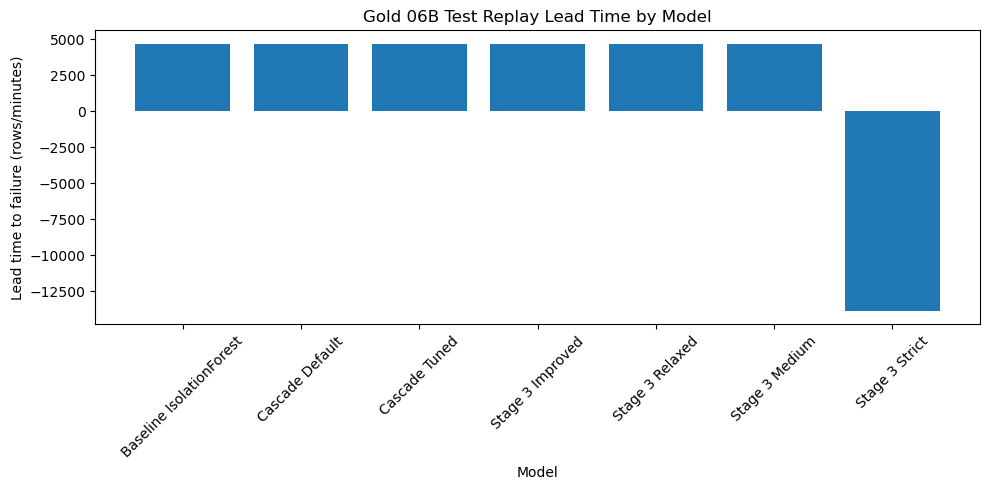

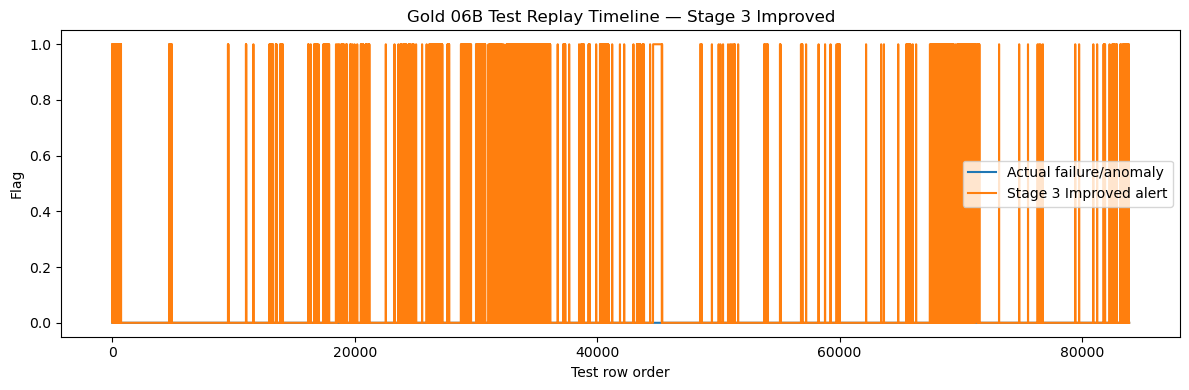

2026-06-18 00:45:13,085 | INFO | capstone.file_io | Saved JSON: /workspace/artifacts/gold/pump/model_replay_validation/summaries/pump__gold06b__test_early_warning_summary.json
2026-06-18 00:45:13,088 | INFO | capstone.gold.test_early_warning_validation | LEDGER | {'ts_utc': '2026-06-18T00:45:13.088044+00:00', 'stage': 'gold_test_early_warning_validation', 'recipe': 'gold_modeling__v001_test_early_warning_validation', 'kind': 'result', 'step': 'gold06b_outputs_saved', 'message': 'Saved Gold 06B test early-warning summaries, comparison artifacts, and plots.', 'why': None, 'consequence': None, 'data': {'stage': 'gold_test_early_warning_validation', 'dataset': 'pump', 'recipe_id': 'gold_modeling__v001_test_early_warning_validation', 'replay_scores_path': '/workspace/artifacts/gold/pump/model_replay_validation/scores/pump__gold06a__test_replay_scores.csv', 'early_warning_summary_path': '/workspace/artifacts/gold/pump/model_replay_validation/summaries/pump__gold06b__test_early_warning_summar

{'stage': 'gold_test_early_warning_validation',
 'dataset': 'pump',
 'recipe_id': 'gold_modeling__v001_test_early_warning_validation',
 'replay_scores_path': '/workspace/artifacts/gold/pump/model_replay_validation/scores/pump__gold06a__test_replay_scores.csv',
 'early_warning_summary_path': '/workspace/artifacts/gold/pump/model_replay_validation/summaries/pump__gold06b__test_early_warning_summary.csv',
 'lead_time_comparison_path': '/workspace/artifacts/gold/pump/model_replay_validation/summaries/pump__gold06b__test_vs_gold05_lead_time_comparison.csv',
 'lead_plot_path': '/workspace/artifacts/gold/pump/model_replay_validation/plots/pump__gold06b__test_lead_time_comparison.png',
 'timeline_plot_path': '/workspace/artifacts/gold/pump/model_replay_validation/plots/pump__gold06b__test_stage3_improved_timeline.png',
 'model_count': 7,
 'gold05_training_lead_time_available': True,
 'note': 'Gold 06B performs Gold 05-style early-warning validation on the replayed held-out test outputs from Go

In [7]:
early_warning_summary_path = VALIDATION_SUMMARY_DIR / f"{DATASET_NAME}__gold06b__test_early_warning_summary.csv"
lead_time_comparison_path = VALIDATION_SUMMARY_DIR / f"{DATASET_NAME}__gold06b__test_vs_gold05_lead_time_comparison.csv"
summary_json_path = VALIDATION_SUMMARY_DIR / f"{DATASET_NAME}__gold06b__test_early_warning_summary.json"
lead_plot_path = VALIDATION_PLOTS_DIR / f"{DATASET_NAME}__gold06b__test_lead_time_comparison.png"
timeline_plot_path = VALIDATION_PLOTS_DIR / f"{DATASET_NAME}__gold06b__test_stage3_improved_timeline.png"

early_warning_summary_dataframe.to_csv(early_warning_summary_path, index=False)
lead_time_comparison_dataframe.to_csv(lead_time_comparison_path, index=False)

# Lead-time bar plot.
plot_df = early_warning_summary_dataframe.dropna(subset=["lead_time_minutes_to_failure"]).copy()
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["plot_run_label"], plot_df["lead_time_minutes_to_failure"])
    ax.set_title("Gold 06B Test Replay Lead Time by Model")
    ax.set_xlabel("Model")
    ax.set_ylabel("Lead time to failure (rows/minutes)")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(lead_plot_path, dpi=150)
    plt.show()

# Simple timeline for the selected/recommended Stage 3 output.
timeline_flag_column = "stage3_improved__cascade_final_flag"
if timeline_flag_column in replay_scores_dataframe.columns:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(replay_scores_dataframe["plot_order_index"], replay_scores_dataframe["actual_failure_flag"], label="Actual failure/anomaly")
    ax.plot(replay_scores_dataframe["plot_order_index"], replay_scores_dataframe[timeline_flag_column], label="Stage 3 Improved alert")
    ax.set_title("Gold 06B Test Replay Timeline — Stage 3 Improved")
    ax.set_xlabel("Test row order")
    ax.set_ylabel("Flag")
    ax.legend()
    fig.tight_layout()
    fig.savefig(timeline_plot_path, dpi=150)
    plt.show()

summary_payload = {
    "stage": CONTEXT_STAGE,
    "dataset": DATASET_NAME,
    "recipe_id": CONTEXT_RECIPE_ID,
    "replay_scores_path": str(REPLAY_SCORES_PATH),
    "early_warning_summary_path": str(early_warning_summary_path),
    "lead_time_comparison_path": str(lead_time_comparison_path),
    "lead_plot_path": str(lead_plot_path),
    "timeline_plot_path": str(timeline_plot_path),
    "model_count": int(len(early_warning_summary_dataframe)),
    "gold05_training_lead_time_available": bool(TRAIN_LEAD_TIME_PATH.exists()),
    "note": (
        "Gold 06B performs Gold 05-style early-warning validation on the replayed held-out test outputs from Gold 06A."
    ),
}

save_json(summary_payload, summary_json_path)

ledger.add(
    kind="result",
    step="gold06b_outputs_saved",
    message="Saved Gold 06B test early-warning summaries, comparison artifacts, and plots.",
    data=summary_payload,
    logger=logger,
)

summary_payload


## 7. Gold 06B interpretation


In [8]:
interpretation = {
    "purpose": "Validate early-warning behavior on replayed held-out test outputs.",
    "input": str(REPLAY_SCORES_PATH),
    "primary_output": str(early_warning_summary_path),
    "comparison_output": str(lead_time_comparison_path),
    "scope": "Gold 05-style early-warning review, but on Gold 06A replayed test-set outputs.",
}

interpretation


{'purpose': 'Validate early-warning behavior on replayed held-out test outputs.',
 'input': '/workspace/artifacts/gold/pump/model_replay_validation/scores/pump__gold06a__test_replay_scores.csv',
 'primary_output': '/workspace/artifacts/gold/pump/model_replay_validation/summaries/pump__gold06b__test_early_warning_summary.csv',
 'comparison_output': '/workspace/artifacts/gold/pump/model_replay_validation/summaries/pump__gold06b__test_vs_gold05_lead_time_comparison.csv',
 'scope': 'Gold 05-style early-warning review, but on Gold 06A replayed test-set outputs.'}